# Plots for Experiments for RQs 1-4

### RQ1 How do ISTA, FISTA, and ADMM compare in terms of convergence speed with respect to iterations and wall-clock time on LASSO problems of moderate dimension?

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Load the raw data
admm_data = np.load('results/ADMM_raw.npz', allow_pickle=True)
fista_data = np.load('results/FISTA_raw.npz', allow_pickle=True)
ista_data = np.load('results/ISTA_raw.npz', allow_pickle=True)

# Function to compute average solution error vs iterations
def get_avg_sol_err_vs_iter(data, n_trials=5):
    iters = data['iter']
    sol_errs = data['solution_error']
    min_len = min(len(it) for it in iters)
    avg_sol_err = np.mean([sol_errs[i][:min_len] for i in range(n_trials)], axis=0)
    avg_iter = iters[0][:min_len]
    return avg_iter, avg_sol_err

# Get data for each algorithm
admm_iter, admm_sol_err = get_avg_sol_err_vs_iter(admm_data)
fista_iter, fista_sol_err = get_avg_sol_err_vs_iter(fista_data)
ista_iter, ista_sol_err = get_avg_sol_err_vs_iter(ista_data)

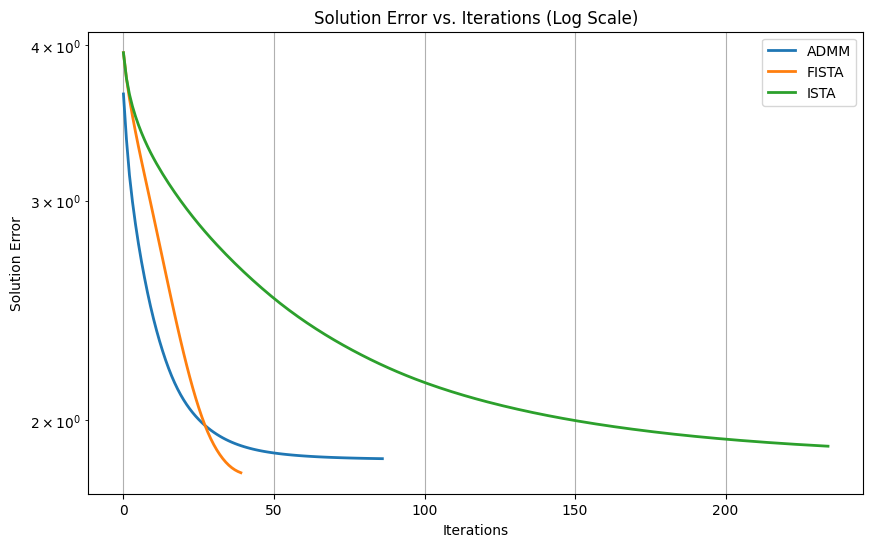

In [4]:
# Plot Solution Error vs. Iterations (log-scale)
plt.figure(figsize=(10, 6))
plt.semilogy(admm_iter, admm_sol_err, label='ADMM', linewidth=2)
plt.semilogy(fista_iter, fista_sol_err, label='FISTA', linewidth=2)
plt.semilogy(ista_iter, ista_sol_err, label='ISTA', linewidth=2)
plt.xlabel('Iterations')
plt.ylabel('Solution Error')
plt.title('Solution Error vs. Iterations (Log Scale)')
plt.legend()
plt.grid(True)
plt.savefig('solution_error_vs_iterations.png')
plt.show()

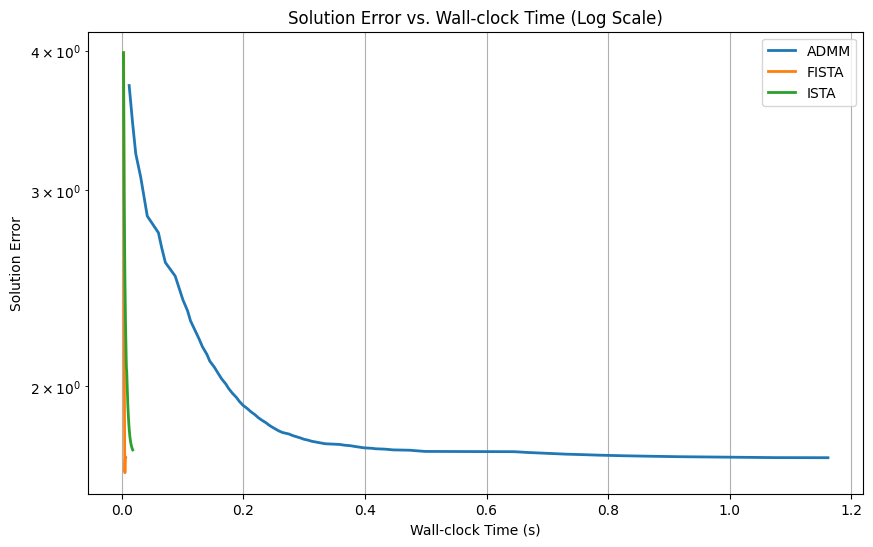

In [5]:
# For time, use the first trial
admm_time = admm_data['time'][0]
admm_sol_err_time = admm_data['solution_error'][0]
fista_time = fista_data['time'][0]
fista_sol_err_time = fista_data['solution_error'][0]
ista_time = ista_data['time'][0]
ista_sol_err_time = ista_data['solution_error'][0]

# Plot Solution Error vs. Wall-clock Time (log-scale)
plt.figure(figsize=(10, 6))
plt.semilogy(admm_time, admm_sol_err_time, label='ADMM', linewidth=2)
plt.semilogy(fista_time, fista_sol_err_time, label='FISTA', linewidth=2)
plt.semilogy(ista_time, ista_sol_err_time, label='ISTA', linewidth=2)
plt.xlabel('Wall-clock Time (s)')
plt.ylabel('Solution Error')
plt.title('Solution Error vs. Wall-clock Time (Log Scale)')
plt.legend()
plt.grid(True)
plt.savefig('solution_error_vs_time.png')
plt.show()


In [6]:
# RQ1: Table for time/iterations to reach fixed tolerance
def compute_convergence_metrics(data, tolerance=1e-6, n_trials=5):
    iters_list = []
    times_list = []
    sparsities_list = []
    for i in range(n_trials):
        sol_err = data['solution_error'][i]
        iters = data['iter'][i]
        times = data['time'][i]
        sparsities = data['sparsity'][i]
        # Find the first index where sol_err <= tolerance
        idx = np.where(sol_err <= tolerance)[0]
        if len(idx) > 0:
            conv_idx = idx[0]
        else:
            conv_idx = len(sol_err) - 1  # last if not reached
        iters_list.append(iters[conv_idx])
        times_list.append(times[conv_idx])
        sparsities_list.append(sparsities[conv_idx])
    return {
        'iterations': np.mean(iters_list),
        'time': np.mean(times_list),
        'sparsity': np.mean(sparsities_list)
    }

tolerance = 1e-6
admm_metrics = compute_convergence_metrics(admm_data, tolerance)
fista_metrics = compute_convergence_metrics(fista_data, tolerance)
ista_metrics = compute_convergence_metrics(ista_data, tolerance)

# Print the table
print("RQ1: Convergence Metrics to Tolerance {:.0e}".format(tolerance))
print("{:<10} {:<12} {:<10} {:<10}".format("Algorithm", "Iterations", "Time (s)", "Sparsity"))
print("-" * 50)
print("{:<10} {:<12.2f} {:<10.4f} {:<10.4f}".format("ADMM", admm_metrics['iterations'], admm_metrics['time'], admm_metrics['sparsity']))
print("{:<10} {:<12.2f} {:<10.4f} {:<10.4f}".format("FISTA", fista_metrics['iterations'], fista_metrics['time'], fista_metrics['sparsity']))
print("{:<10} {:<12.2f} {:<10.4f} {:<10.4f}".format("ISTA", ista_metrics['iterations'], ista_metrics['time'], ista_metrics['sparsity']))


RQ1: Convergence Metrics to Tolerance 1e-06
Algorithm  Iterations   Time (s)   Sparsity  
--------------------------------------------------
ADMM       105.80       0.7015     158.6000  
FISTA      58.00        0.0055     59.4000   
ISTA       275.80       0.0137     59.0000   


## RQ2: How does the conditioning of A (well-conditioned vs. highly correlated features) affect the relative performance of these methods?

In [7]:
# RQ2: Plots for iterations and time vs condition number for iid and toeplitz
condition_numbers = [5, 10, 50, 100, 500]
structures = ['iid', 'toeplitz']
algorithms = ['admm', 'fista', 'ista']

def load_rq2_data(struct, cond, algo):
    filename = f'results/{struct}_cond{cond}_{algo}_agg.npz'
    data = np.load(filename, allow_pickle=True)
    return {
        'iters_mean': data['iters_mean'],
        'time_to_tol_mean': data['time_to_tol_mean']
    }


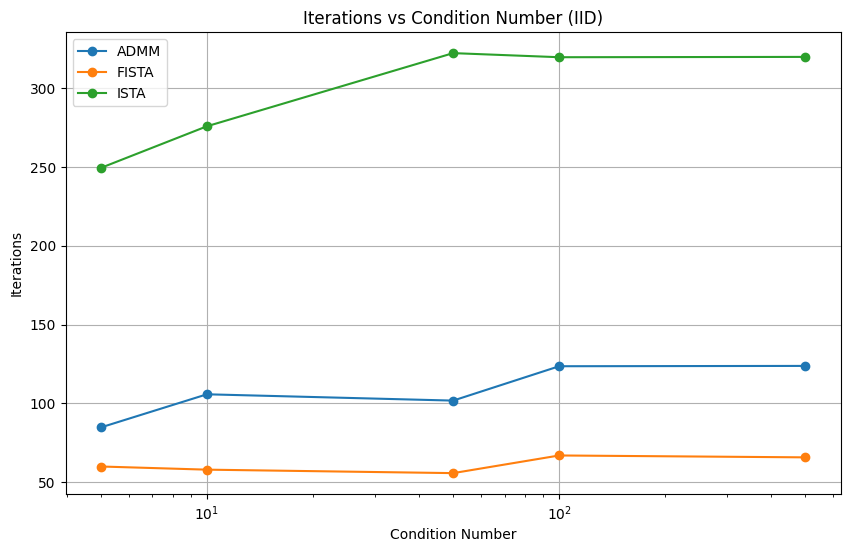

In [8]:
# For iid
iid_iters = {algo: [] for algo in algorithms}
iid_times = {algo: [] for algo in algorithms}
for cond in condition_numbers:
    for algo in algorithms:
        data = load_rq2_data('iid', cond, algo)
        iid_iters[algo].append(data['iters_mean'])
        iid_times[algo].append(data['time_to_tol_mean'])

# Plot Iterations vs Condition Number for iid
plt.figure(figsize=(10, 6))
for algo in algorithms:
    plt.plot(condition_numbers, iid_iters[algo], marker='o', label=algo.upper())
plt.xlabel('Condition Number')
plt.ylabel('Iterations')
plt.title('Iterations vs Condition Number (IID)')
plt.legend()
plt.grid(True)
plt.xscale('log')
plt.savefig('rq2_iid_iterations.png')
plt.show()


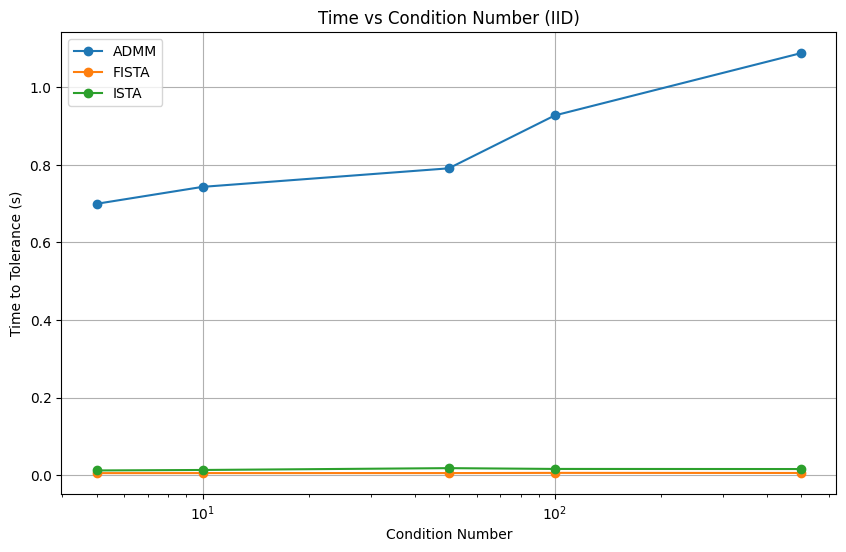

In [9]:
# Plot Time vs Condition Number for iid
plt.figure(figsize=(10, 6))
for algo in algorithms:
    plt.plot(condition_numbers, iid_times[algo], marker='o', label=algo.upper())
plt.xlabel('Condition Number')
plt.ylabel('Time to Tolerance (s)')
plt.title('Time vs Condition Number (IID)')
plt.legend()
plt.grid(True)
plt.xscale('log')
plt.savefig('rq2_iid_time.png')
plt.show()

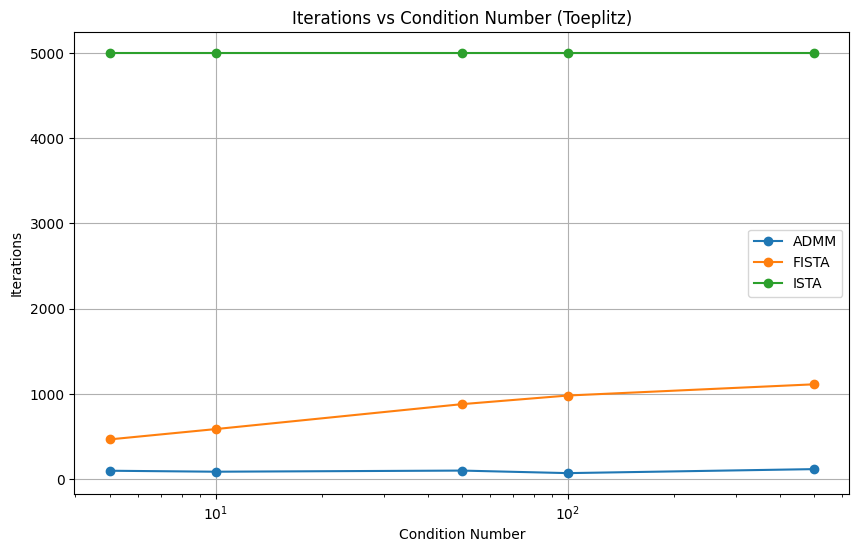

In [10]:
# For toeplitz
toeplitz_iters = {algo: [] for algo in algorithms}
toeplitz_times = {algo: [] for algo in algorithms}
for cond in condition_numbers:
    for algo in algorithms:
        data = load_rq2_data('toeplitz', cond, algo)
        toeplitz_iters[algo].append(data['iters_mean'])
        toeplitz_times[algo].append(data['time_to_tol_mean'])

# Plot Iterations vs Condition Number for toeplitz
plt.figure(figsize=(10, 6))
for algo in algorithms:
    plt.plot(condition_numbers, toeplitz_iters[algo], marker='o', label=algo.upper())
plt.xlabel('Condition Number')
plt.ylabel('Iterations')
plt.title('Iterations vs Condition Number (Toeplitz)')
plt.legend()
plt.grid(True)
plt.xscale('log')
plt.savefig('rq2_toeplitz_iterations.png')
plt.show()

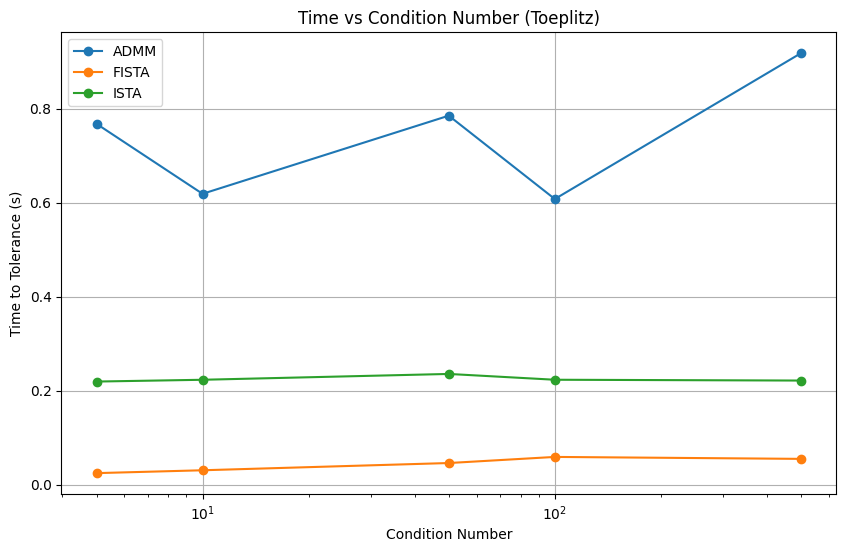

In [11]:
# Plot Time vs Condition Number for toeplitz
plt.figure(figsize=(10, 6))
for algo in algorithms:
    plt.plot(condition_numbers, toeplitz_times[algo], marker='o', label=algo.upper())
plt.xlabel('Condition Number')
plt.ylabel('Time to Tolerance (s)')
plt.title('Time vs Condition Number (Toeplitz)')
plt.legend()
plt.grid(True)
plt.xscale('log')
plt.savefig('rq2_toeplitz_time.png')
plt.show()

## RQ3: How sensitive are the algorithms to hyperparameters such as the step size (for ISTA/FISTA) and the penalty parameter ρ (for ADMM)?

In [12]:
# RQ3: Plots for hyperparameters vs iterations/time
alphas = [0.1, 0.5, 0.9, 1.0, 1.1]
rhos = [0.01, 0.1, 1, 10, 100]

# Load data for ISTA
ista_iters = []
ista_times = []
for alpha in alphas:
    data = np.load(f'results/ista_alpha{alpha}_agg.npz', allow_pickle=True)
    ista_iters.append(data['iters_mean'])
    ista_times.append(data['time_mean'])


# Load data for FISTA
fista_iters = []
fista_times = []
for alpha in alphas:
    data = np.load(f'results/fista_alpha{alpha}_agg.npz', allow_pickle=True)
    fista_iters.append(data['iters_mean'])
    fista_times.append(data['time_mean'])

# Load data for ADMM
admm_iters = []
admm_times = []
for rho in rhos:
    data = np.load(f'results/admm_rho{rho}_agg.npz', allow_pickle=True)
    admm_iters.append(data['iters_mean'])
    admm_times.append(data['time_mean'])

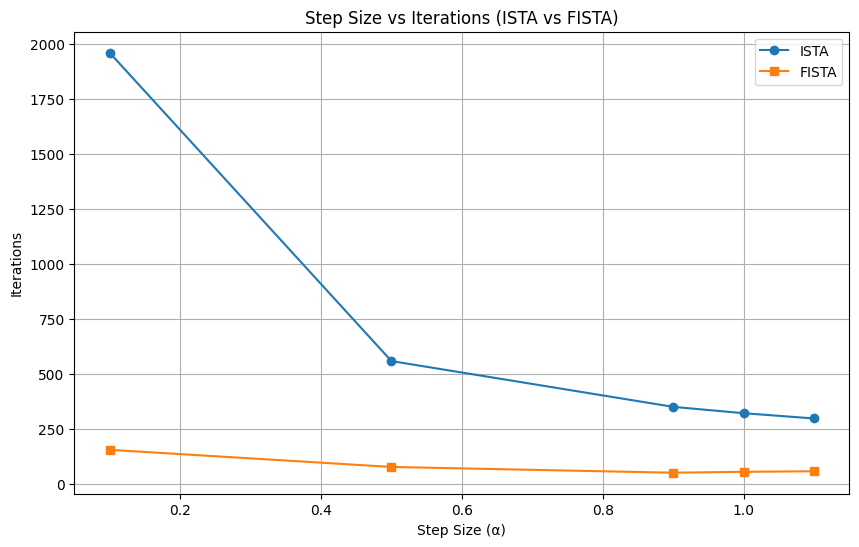

In [20]:
# Plot Step size vs Iterations for ISTA
plt.figure(figsize=(10, 6))
plt.plot(alphas, ista_iters, marker='o', label='ISTA')
plt.plot(alphas, fista_iters, marker='s', label='FISTA')
plt.xlabel('Step Size (α)')
plt.ylabel('Iterations')
plt.title('Step Size vs Iterations (ISTA vs FISTA)')
plt.legend()
plt.grid(True)
plt.savefig('rq3_step_size_iterations_combined.png')
plt.show()

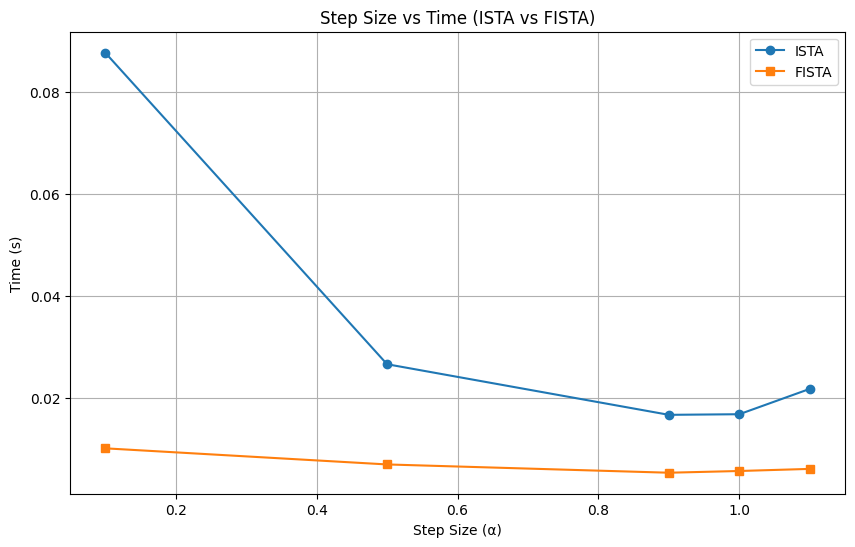

In [21]:
# Plot Step size vs Time for ISTA and FISTA
plt.figure(figsize=(10, 6))
plt.plot(alphas, ista_times, marker='o', label='ISTA')
plt.plot(alphas, fista_times, marker='s', label='FISTA')
plt.xlabel('Step Size (α)')
plt.ylabel('Time (s)')
plt.title('Step Size vs Time (ISTA vs FISTA)')
plt.legend()
plt.grid(True)
plt.savefig('rq3_step_time_combined.png')
plt.show()

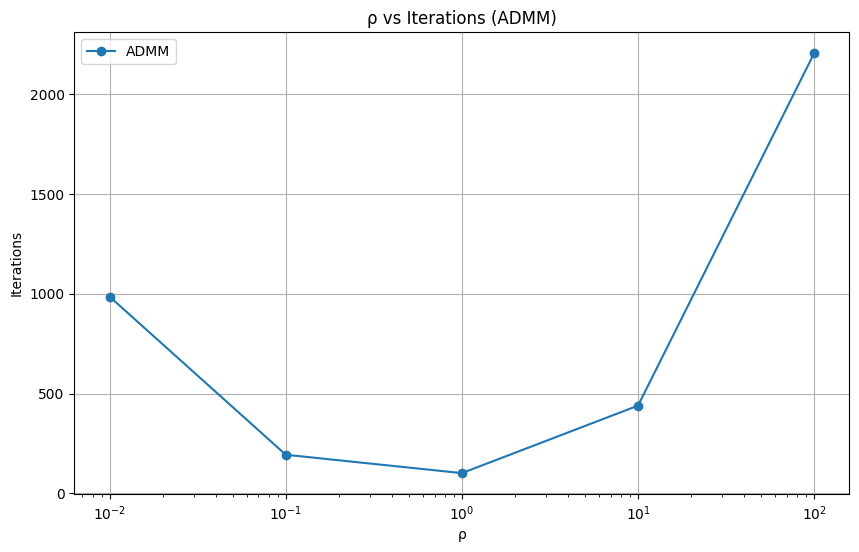

In [17]:
# Plot ρ vs Iterations for ADMM
plt.figure(figsize=(10, 6))
plt.plot(rhos, admm_iters, marker='o', label='ADMM')
plt.xlabel('ρ')
plt.ylabel('Iterations')
plt.title('ρ vs Iterations (ADMM)')
plt.legend()
plt.grid(True)
plt.xscale('log')
plt.savefig('rq3_admm_rho_iterations.png')
plt.show()

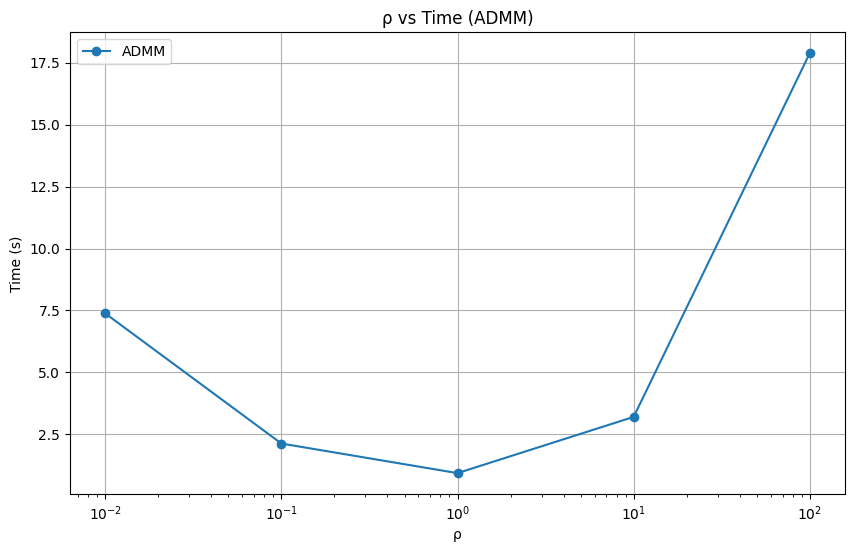

In [18]:
# Plot ρ vs Time for ADMM
plt.figure(figsize=(10, 6))
plt.plot(rhos, admm_times, marker='o', label='ADMM')
plt.xlabel('ρ')
plt.ylabel('Time (s)')
plt.title('ρ vs Time (ADMM)')
plt.legend()
plt.grid(True)
plt.xscale('log')
plt.savefig('rq3_admm_rho_time.png')
plt.show()

## RQ4 On Small Real dataset:


Real-Data Evaluation Metrics (averaged over trials):
Algo         Test MSE   Test MAE    Test R2   Nonzeros  Train MSE
----------------------------------------------------------------------
ISTA       27973.3076   157.8105    -4.2798       10.0 25690.4808
FISTA      27962.0223   157.7806    -4.2777       10.0 25684.2711
ADMM       27960.3088   157.7770    -4.2774       10.0 25684.0953


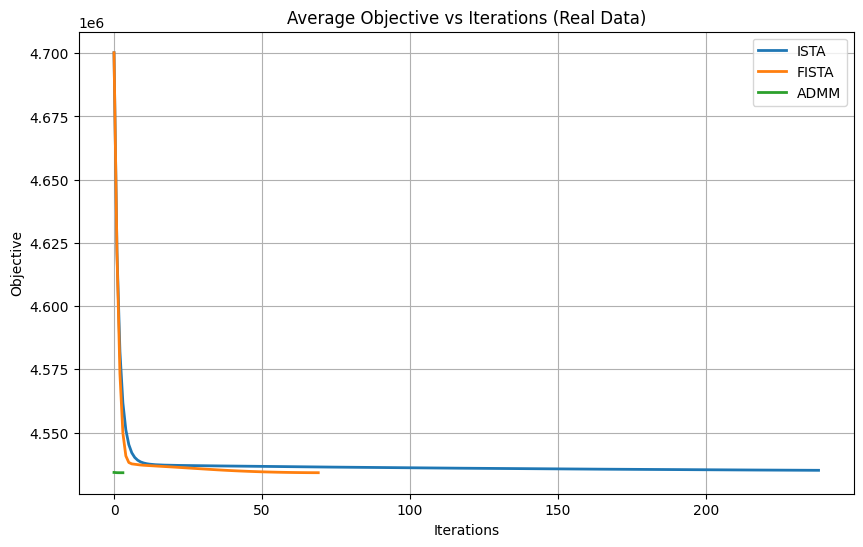

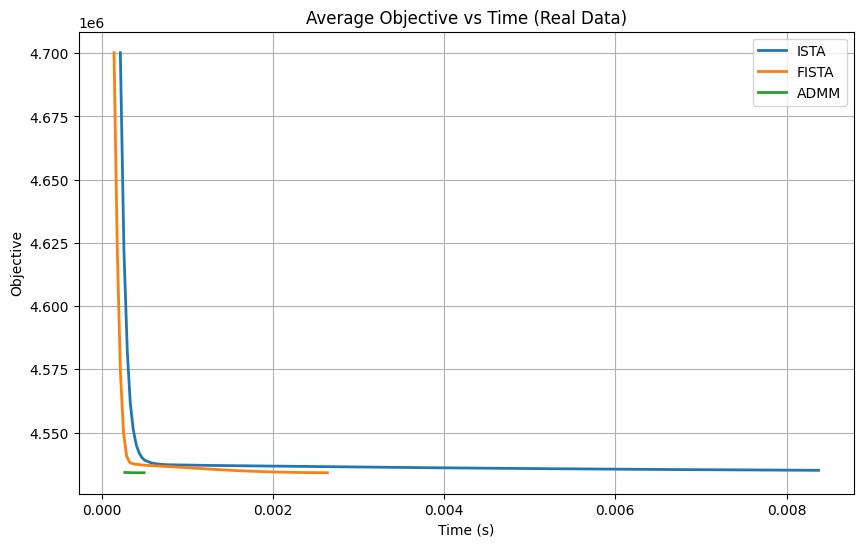

In [19]:
import experiments_real
aggregated_results = experiments_real.run_real_experiment()
experiments_real.plot_real_experiment(aggregated_results)